In [ ]:
import tensorflow as tf
from random import shuffle
import os
import json
import numpy as np
from itertools import product
import torch
import torchvision.transforms as transforms
import os
from PIL import Image
from tensorflow import keras
from keras.models import load_model
from tqdm import tqdm
from skimage.transform import resize
from helpers import classwise_metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from evaluate_qnns import get_data, get_xcnn_heatmap, grad_cam, calculate_explainability
from helpers import classwise_metrics

import tensorflow as tf
from itertools import product
from random import shuffle
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import History 
import warnings
warnings.filterwarnings("ignore")

device = torch.device('cpu')
xcnn = torch.load('./Models/Model_TinyImageNet_128.net', map_location=torch.device('cpu')).to(device)

train_test_split = 0.75
def MyModel(x_train, max_class_allowed, optimizer = 'nadam'):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.Input(shape=(x_train[0].shape)),
        keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.01),
        keras.layers.Dense(400, activation="sigmoid"),
        keras.layers.Dense(100, activation="sigmoid"),
        keras.layers.Dropout(0.01),
        keras.layers.Dense(50, activation="sigmoid"),
        keras.layers.Dense(max_class_allowed, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model
def train_qnn_model(encoding, ansatz, filter_size, optimizer):
    train, test =  [],[]
    dirpath = './tiny-imagenet-200/train'
    wnids = os.listdir(dirpath) 
    max_class_allowed = len(wnids)
    for class_index, class_path in enumerate(wnids):
        data = []
        images = os.listdir(dirpath + "/" + class_path + "/images/")
        for img in images:
            if img.endswith("-"+encoding+"-"+ansatz+"-"+str(filter_size)+".npy"):
                img = np.load(dirpath + "/" + class_path + "/images/"+img)
                data.append((img, class_index))
        
        last_index = int(train_test_split*len(data))
        train = train + data[:last_index]
        test = test + data[last_index:]

    shuffle(train)
    shuffle(test)

    train_x, train_y, test_x, test_y = [], [], [], []
    for train_item in train:
        train_x.append(train_item[0])
        train_y.append(train_item[1])

    for test_item in test:
        test_x.append(test_item[0])
        test_y.append(test_item[1])

    train_x = np.array(train_x)
    train_y = np.array(train_y)
    test_x = np.array(test_x)
    test_y = np.array(test_y)

    history = History()
    q_model = MyModel(train_x, max_class_allowed, optimizer = optimizer)

    n_epochs = 500
    q_history = q_model.fit(
        train_x,
        train_y,
        validation_data=(test_x[:len(test_x)//4], test_y[:len(test_y)//4]),
        batch_size=32,
        epochs=n_epochs,
        verbose=2,
        callbacks=[history])
    return q_model

In [2]:
optimizer = {}
optimizer[('angle','basic')] = 'nadam'
optimizer[('angle','strong')] = 'adam'
optimizer[('amplitude','basic')] = 'nadam'
optimizer[('amplitude','strong')] = 'nadam'

enocdings = ['angle','amplitude']
ansatz = ['basic','strong']
kernel_sizes = [2]
num_times_to_repeat = 10
store = {}
for encoding_type, ansatz_type, kernel_size in product(enocdings, ansatz, kernel_sizes):
    print("Current config:", encoding_type, ansatz_type)
    qnn_list = []
    for curr_rep in range(num_times_to_repeat):
        print("Current iter:",curr_rep)
        qnn = (train_qnn_model(encoding_type, ansatz_type, kernel_size, optimizer[(encoding_type, ansatz_type)]))
        x_original, x_quanv, y = get_data(encoding_type, ansatz_type, kernel_size)
        explanilibity = []
        sum_explanilibity = 0
        for i in tqdm(range(len(x_original))):
            heatmap_qnn = grad_cam(qnn, tf.convert_to_tensor([x_quanv[i]]), y[i])
            heatmap_xcnn = get_xcnn_heatmap(x_original[i])
            ret_val = int(calculate_explainability(heatmap_qnn, heatmap_xcnn))
            if ret_val != -1:
                explanilibity.append((int(y[i]), ret_val))
                sum_explanilibity = sum_explanilibity + ret_val

        predictions = [tf.argmax(pred).numpy() for pred in qnn.predict(tf.convert_to_tensor(x_quanv))]
        class_wise_metrics = {}
        for class_label in set(y):
            class_wise_metrics[int(class_label)] = classwise_metrics(y, predictions, explanilibity, class_label)
        print("class metrics:", class_wise_metrics)
        store[(encoding_type, ansatz_type, curr_rep, 0)] = class_wise_metrics[0] 
        store[(encoding_type, ansatz_type, curr_rep, 1)] = class_wise_metrics[1] 
        store[(encoding_type, ansatz_type, curr_rep, 2)] = class_wise_metrics[2] 
        store[(encoding_type, ansatz_type, curr_rep, 3)] = class_wise_metrics[3] 
        print("-------------------------------------------------------------------------\n\n")

Current config: angle basic
Current iter: 0
Epoch 1/500
46/46 - 1s - 22ms/step - accuracy: 0.3435 - loss: 1.3404 - val_accuracy: 0.4083 - val_loss: 1.2642
Epoch 2/500
46/46 - 0s - 3ms/step - accuracy: 0.4386 - loss: 1.2344 - val_accuracy: 0.4250 - val_loss: 1.2064
Epoch 3/500
46/46 - 0s - 3ms/step - accuracy: 0.4913 - loss: 1.1655 - val_accuracy: 0.4583 - val_loss: 1.1743
Epoch 4/500
46/46 - 0s - 3ms/step - accuracy: 0.5191 - loss: 1.1120 - val_accuracy: 0.5083 - val_loss: 1.1545
Epoch 5/500
46/46 - 0s - 3ms/step - accuracy: 0.5524 - loss: 1.0769 - val_accuracy: 0.4667 - val_loss: 1.1193
Epoch 6/500
46/46 - 0s - 3ms/step - accuracy: 0.5663 - loss: 1.0371 - val_accuracy: 0.4500 - val_loss: 1.1466
Epoch 7/500
46/46 - 0s - 3ms/step - accuracy: 0.5808 - loss: 1.0074 - val_accuracy: 0.4000 - val_loss: 1.2173
Epoch 8/500
46/46 - 0s - 3ms/step - accuracy: 0.6190 - loss: 0.9757 - val_accuracy: 0.4833 - val_loss: 1.1824
Epoch 9/500
46/46 - 0s - 3ms/step - accuracy: 0.6329 - loss: 0.9318 - val_a

100%|██████████| 1922/1922 [00:42<00:00, 45.68it/s]


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
class metrics: {0: (0.9218009478672986, np.float64(0.9593094944512947), np.float64(1.0), np.float64(0.9218009478672986), 35.40521327014218), 1: (0.844, np.float64(0.9154013015184381), np.float64(1.0), np.float64(0.844), 19.856), 2: (0.87, np.float64(0.93048128342246), np.float64(1.0), np.float64(0.87), 17.186), 3: (0.874, np.float64(0.9327641408751334), np.float64(1.0), np.float64(0.874), 18.698)}
-------------------------------------------------------------------------


Current iter: 1
Epoch 1/500
46/46 - 1s - 17ms/step - accuracy: 0.3359 - loss: 1.3608 - val_accuracy: 0.3500 - val_loss: 1.2800
Epoch 2/500
46/46 - 0s - 3ms/step - accuracy: 0.4268 - loss: 1.2379 - val_accuracy: 0.4167 - val_loss: 1.2375
Epoch 3/500
46/46 - 0s - 3ms/step - accuracy: 0.4997 - loss: 1.1714 - val_accuracy: 0.4333 - val_loss: 1.1693
Epoch 4/500
46/46 - 0s - 3ms/step - accuracy: 0.5232 - loss: 1.1160 - val_accuracy: 0.5167 - val_loss: 1.1594
Epoch 5/500
46/46 - 0s - 

100%|██████████| 1922/1922 [00:40<00:00, 47.31it/s]


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
class metrics: {0: (0.9123222748815166, np.float64(0.9541511771995044), np.float64(1.0), np.float64(0.9123222748815166), 35.09478672985782), 1: (0.856, np.float64(0.9224137931034483), np.float64(1.0), np.float64(0.856), 19.594), 2: (0.86, np.float64(0.9247311827956989), np.float64(1.0), np.float64(0.86), 16.6), 3: (0.884, np.float64(0.9384288747346072), np.float64(1.0), np.float64(0.884), 19.042)}
-------------------------------------------------------------------------


Current iter: 2
Epoch 1/500
46/46 - 1s - 15ms/step - accuracy: 0.3539 - loss: 1.3323 - val_accuracy: 0.4000 - val_loss: 1.2816
Epoch 2/500
46/46 - 0s - 3ms/step - accuracy: 0.4303 - loss: 1.2217 - val_accuracy: 0.4583 - val_loss: 1.2170
Epoch 3/500
46/46 - 0s - 4ms/step - accuracy: 0.4844 - loss: 1.1588 - val_accuracy: 0.5333 - val_loss: 1.1682
Epoch 4/500
46/46 - 0s - 3ms/step - accuracy: 0.5253 - loss: 1.1110 - val_accuracy: 0.5167 - val_loss: 1.1537
Epoch 5/500
46/46 - 0s - 

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
class metrics: {0: (0.924, np.float64(0.9604989604989606), np.float64(1.0), np.float64(0.924), 35.56425702811245), 1: (0.904, np.float64(0.9495798319327731), np.float64(1.0), np.float64(0.904), 21.424), 2: (0.834, np.float64(0.9094874591057798), np.float64(1.0), np.float64(0.834), 18.688), 3: (0.862, np.float64(0.9258861439312567), np.float64(1.0), np.float64(0.862), 19.482)}
-------------------------------------------------------------------------


Current iter: 8
Epoch 1/500
47/47 - 1s - 17ms/step - accuracy: 0.3067 - loss: 1.3452 - val_accuracy: 0.3600 - val_loss: 1.2530
Epoch 2/500
47/47 - 0s - 3ms/step - accuracy: 0.3813 - loss: 1.2354 - val_accuracy: 0.4320 - val_loss: 1.1695
Epoch 3/500
47/47 - 0s - 3ms/step - accuracy: 0.4273 - loss: 1.1921 - val_accuracy: 0.5120 - val_loss: 1.1224
Epoch 4/500
47/47 - 0s - 3ms/step - accuracy: 0.4493 - loss: 1.1529 - val_accuracy: 0.4960 - val_loss: 1.0924
Epoch 5/500
47/47 - 0s - 3ms/step - accuracy: 0

100%|██████████| 2000/2000 [00:47<00:00, 42.43it/s]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
class metrics: {0: (0.94, np.float64(0.9690721649484536), np.float64(1.0), np.float64(0.94), 35.416498993963785), 1: (0.712, np.float64(0.8317757009345794), np.float64(1.0), np.float64(0.712), 21.254), 2: (0.844, np.float64(0.9154013015184381), np.float64(1.0), np.float64(0.844), 18.962), 3: (0.918, np.float64(0.9572471324296142), np.float64(1.0), np.float64(0.918), 19.07)}
-------------------------------------------------------------------------


Current iter: 9
Epoch 1/500
47/47 - 1s - 17ms/step - accuracy: 0.3420 - loss: 1.3450 - val_accuracy: 0.3600 - val_loss: 1.2972
Epoch 2/500
47/47 - 0s - 3ms/step - accuracy: 0.4087 - loss: 1.2433 - val_accuracy: 0.4480 - val_loss: 1.1955
Epoch 3/500
47/47 - 0s - 3ms/step - accuracy: 0.4493 - loss: 1.1901 - val_accuracy: 0.4560 - val_loss: 1.1615
Epoch 4/500
47/47 - 0s - 3ms/step - accuracy: 0.4520 - loss: 1.1660 - val_accuracy: 0.4720 - val_loss: 1.1653
Epoch 5/500
47/47 - 0s - 3ms/step - accuracy: 0.4

100%|██████████| 2000/2000 [00:47<00:00, 42.26it/s]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
class metrics: {0: (0.912, np.float64(0.9539748953974896), np.float64(1.0), np.float64(0.912), 35.185110663983906), 1: (0.88, np.float64(0.9361702127659575), np.float64(1.0), np.float64(0.88), 20.874), 2: (0.81, np.float64(0.8950276243093923), np.float64(1.0), np.float64(0.81), 18.264), 3: (0.886, np.float64(0.9395546129374337), np.float64(1.0), np.float64(0.886), 18.608)}
-------------------------------------------------------------------------




In [87]:
import pandas as pd 
df = pd.DataFrame(columns=["Encoding","Entanglement","Repeatition","Class","Accuracy","F1-Score","Precision","Recall","Explainability"])

for i,key in enumerate(store):
    row = list(key) 
    row = row + [store[key][0]]
    row = row + [store[key][1].item()]
    row = row + [store[key][2].item()]
    row = row + [store[key][3].item()]
    row = row + [store[key][4]]
    df.loc[i] = row
df.to_csv('multiple_run.csv',index = False)

# Display Accuracy and F1-Score with error bars

In [ ]:
def plot_accuracy_f1_score(encoding_type, entanglement_type):
    class_label = ['Jellyfish', 'Cat', 'Grasshopper', 'Dog']
    temp_df = df[(df.Entanglement == entanglement_type) & (df.Encoding == encoding_type)]

    accuracy_error, f1_score_error = [],[]
    for class_index in range(len(class_label)):
        accuracy_error.append(np.std(list(temp_df[temp_df['Class'] == class_index]['Accuracy'])).item())
        f1_score_error.append(np.std(list(temp_df[temp_df['Class'] == class_index]['F1-Score'])).item())
    
    accuracy = list(temp_df.groupby(by=["Class"], dropna=False).mean(numeric_only=True)['Accuracy'])
    f1_score = list(temp_df.groupby(by=["Class"], dropna=False).mean(numeric_only=True)['F1-Score'])

    min_accuracy = list(temp_df.groupby(by=["Class"], dropna=False).min()['Accuracy'])
    min_f1_score = list(temp_df.groupby(by=["Class"], dropna=False).min()['F1-Score'])

    max_accuracy = list(temp_df.groupby(by=["Class"], dropna=False).max()['Accuracy'])
    max_f1_score = list(temp_df.groupby(by=["Class"], dropna=False).max()['F1-Score'])

    fig, ax = plt.subplots(figsize = (10,8))
    width = 0.35
    x = np.arange(len(class_label))

    bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', yerr = accuracy_error, alpha=0.6)
    bars2 = ax.bar(x + width/2, f1_score, width, label='F1-score', yerr = f1_score_error, alpha=0.6)

    ax.set_xlabel('Classes',fontsize=20)
    ax.set_ylabel('Scores',fontsize=20)
    ax.set_title("Accuracy and F1-Score per class: Encoding: "+encoding_type+" | "+"Entanglement: "+entanglement_type,fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(class_label,fontsize=20)
    ax.set_ylim(0, 1.3)  # Scores range from 0 to 1
    ax.grid(True, linestyle='--')
    ax.legend(fontsize=20)

    # Show values on bars
    for i,bar in enumerate(bars1 + bars2):
        height = bar.get_height()
        y_pos = 0
        if i < 4:
            y_pos = max_accuracy[i]
        else:
            y_pos = max_f1_score[i%4]
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, y_pos),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=20)
    
    return (accuracy, accuracy_error, min_accuracy, max_accuracy), (f1_score, f1_score_error, min_f1_score, max_f1_score) 
    

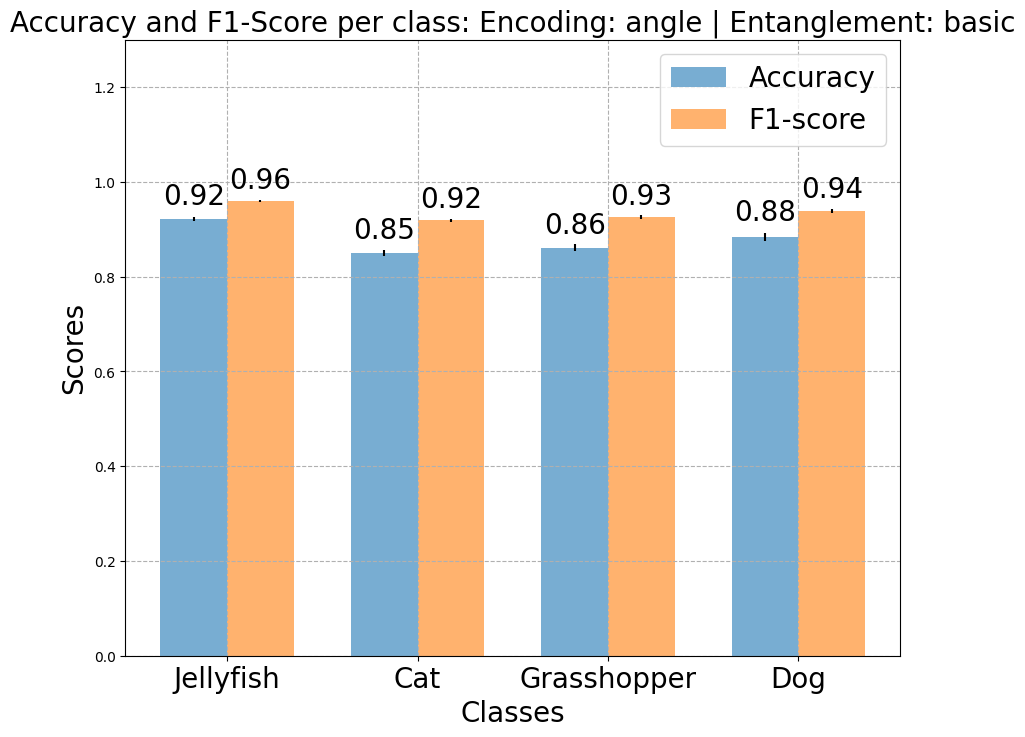

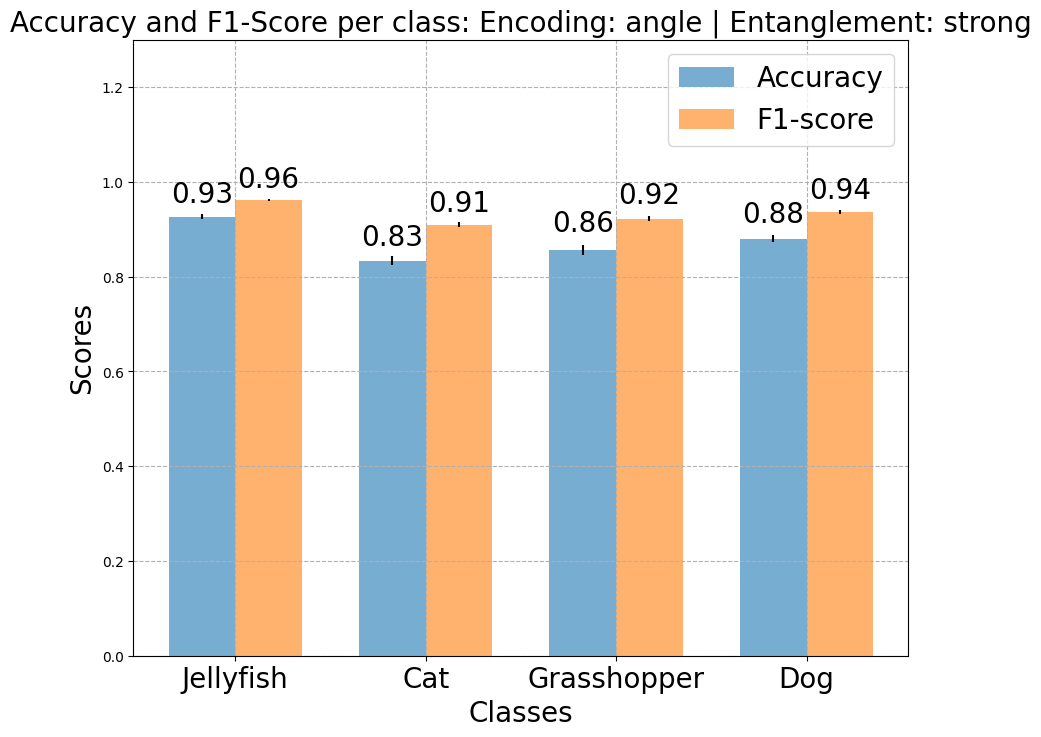

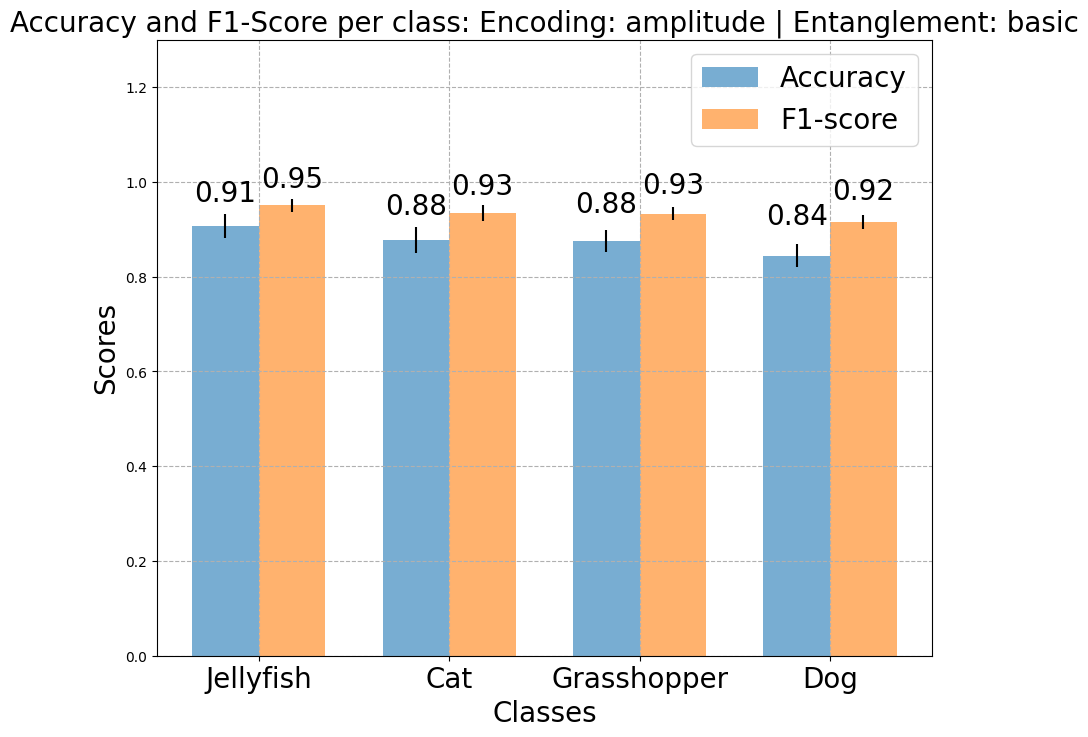

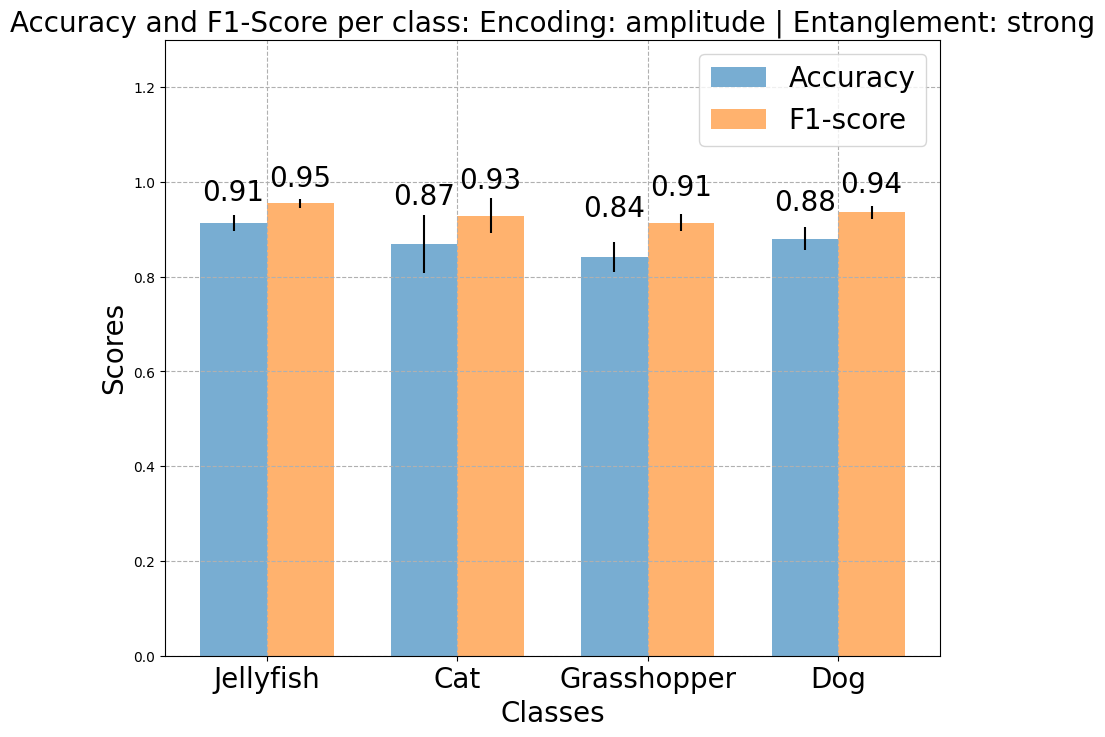

In [179]:
enocdings = ['angle','amplitude']
ansatz = ['basic','strong']
kernel_sizes = [2]
avg_df = pd.DataFrame(columns=["Encoding","Entanglement","Class",
                           "Mean Accuracy", "Accuracy Stdev", "Min Accuracy", "Max Accuracy",
                           "Mean F1-Score", "F1-Score Stdev", "Min F1-Score", "Max F1-Score"])

for encoding_type, ansatz_type, kernel_size in product(enocdings, ansatz, kernel_sizes):
    (accuracy, accuracy_error, min_accuracy, max_accuracy), (f1_score, f1_score_error, min_f1_score, max_f1_score)  = plot_accuracy_f1_score(encoding_type, ansatz_type)
    for i in range(4):
        row = [encoding_type, ansatz_type, i, accuracy[i], accuracy_error[i], min_accuracy[i], max_accuracy[i], f1_score[i], f1_score_error[i], min_f1_score[i], max_f1_score[i]]
        avg_df.loc[len(avg_df)] = row

In [189]:
final_avg_df = pd.DataFrame(columns=["Encoding", "Entanglement","Mean Accuracy", "Accuracy Stdev", "Min Accuracy", "Max Accuracy", "Mean F1-Score", "F1-Score Stdev", "Min F1-Score", "Max F1-Score"])
for encoding_type, ansatz_type, kernel_size in product(enocdings, ansatz, kernel_sizes):
    temp_df = avg_df[(avg_df.Entanglement == ansatz_type) & (avg_df.Encoding == encoding_type)]
    temp_df = (temp_df.mean(numeric_only=True))
    row = [encoding_type, ansatz_type, 
           temp_df["Mean Accuracy"], temp_df["Accuracy Stdev"], temp_df["Min Accuracy"], temp_df["Max Accuracy"],
           temp_df["Mean F1-Score"], temp_df["F1-Score Stdev"], temp_df["Min F1-Score"], temp_df["Max F1-Score"],]
    final_avg_df.loc[len(final_avg_df)] = row
final_avg_df

,Encoding,Entanglement,Mean Accuracy,Accuracy Stdev,Min Accuracy,Max Accuracy,Mean F1-Score,F1-Score Stdev,Min F1-Score,Max F1-Score
0,angle,basic,0.879300,0.006734,0.867581,0.889820,0.935535,0.003831,0.928840,0.941472
1,angle,strong,0.874156,0.007940,0.859150,0.886406,0.932474,0.004565,0.923725,0.939456
2,amplitude,basic,0.875789,0.025156,0.821566,0.912119,0.933439,0.014457,0.901945,0.953955
3,amplitude,strong,0.875950,0.032934,0.812500,0.924000,0.933241,0.019253,0.895170,0.960451


# Display Explainability with error bars

In [217]:
def plot_exp(encoding_type, entanglement_type):
    class_label = ['Jellyfish', 'Cat', 'Grasshopper', 'Dog']
    temp_df = df[(df.Entanglement == entanglement_type) & (df.Encoding == encoding_type)]

    exp_error = []
    for class_index in range(len(class_label)):
        exp_error.append(np.std(list(temp_df[temp_df['Class'] == class_index]['Explainability'])).item())
    
    mean = list(temp_df.groupby(by=["Class"], dropna=False).mean(numeric_only=True)['Explainability'])
    min = list(temp_df.groupby(by=["Class"], dropna=False).min()['Explainability'])
    max = list(temp_df.groupby(by=["Class"], dropna=False).max()['Explainability'])

    fig, ax = plt.subplots(figsize = (10,8))
    width = 0.5
    x = np.arange(len(class_label))

    bars1 = ax.bar(x - width/2, mean, width, yerr = exp_error, color = 'green',alpha=0.6)

    ax.set_xlabel('Classes',fontsize=20)
    ax.set_ylabel(r'$\mathcal{E}_{QNN}$',fontsize=20)
    ax.set_title("Explainibility "+ r'$\mathcal{E}_{QNN}$' + " per class: Encoding: "+encoding_type+" | "+"Entanglement: "+entanglement_type,fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(class_label,fontsize=20)
    ax.set_ylim(0, 40)  # Scores range from 0 to 1
    ax.grid(True, linestyle='--')
    # ax.legend(fontsize=20)

    # Show values on bars
    for i,bar in enumerate(bars1):
        height = bar.get_height()
        y_pos = max[i]
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, y_pos),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=20)
    
    return (mean, exp_error, min, max)
    

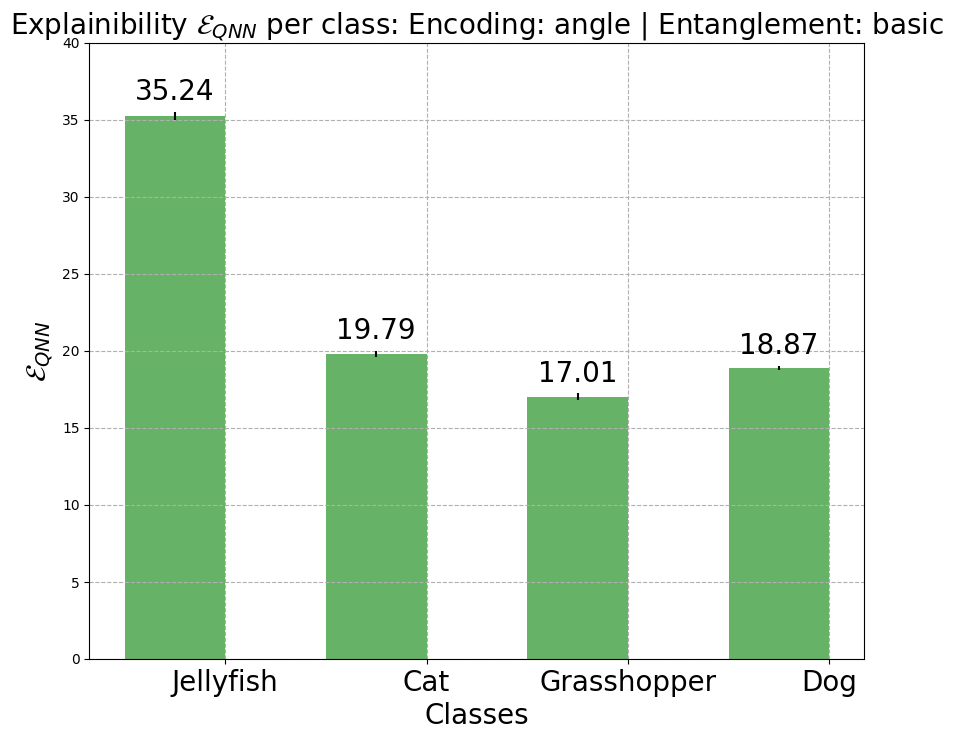

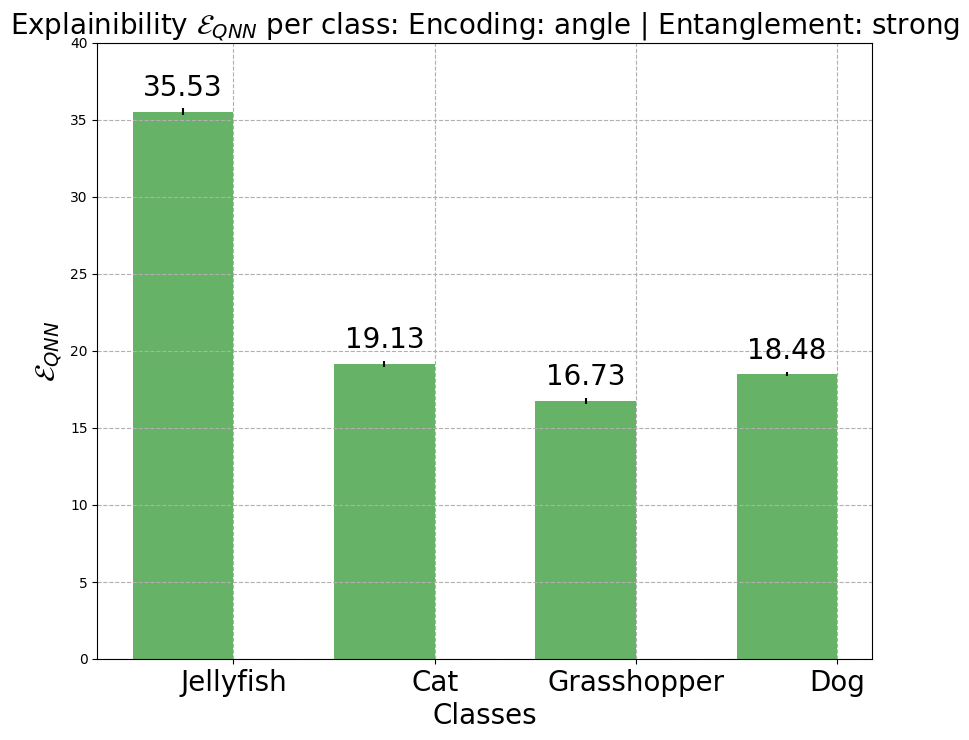

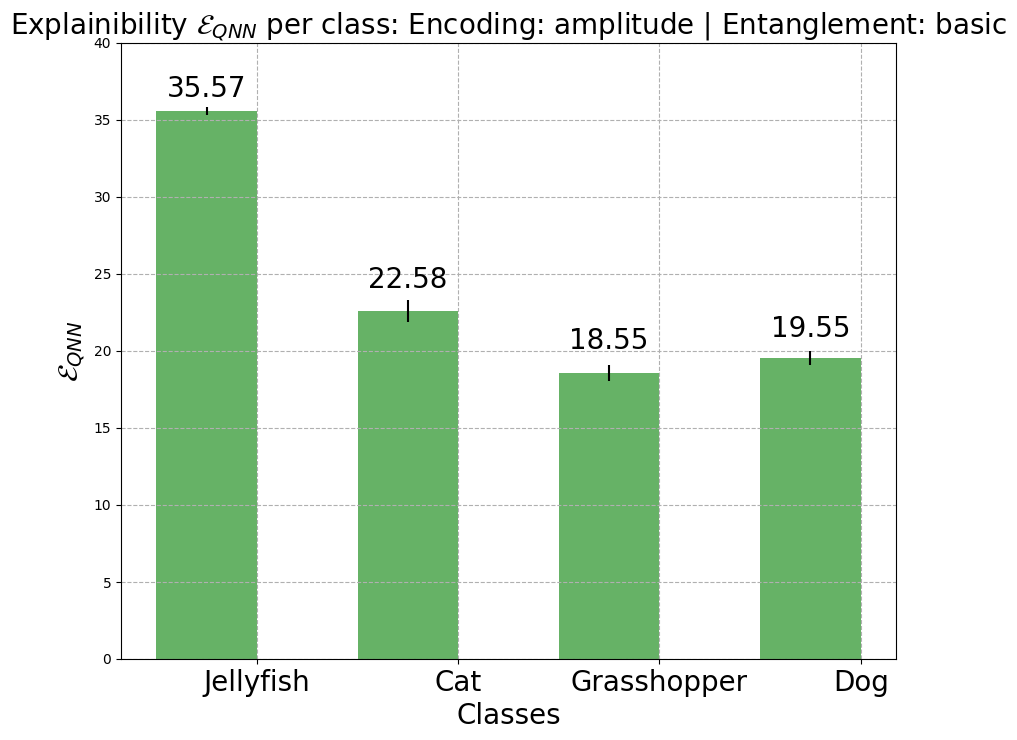

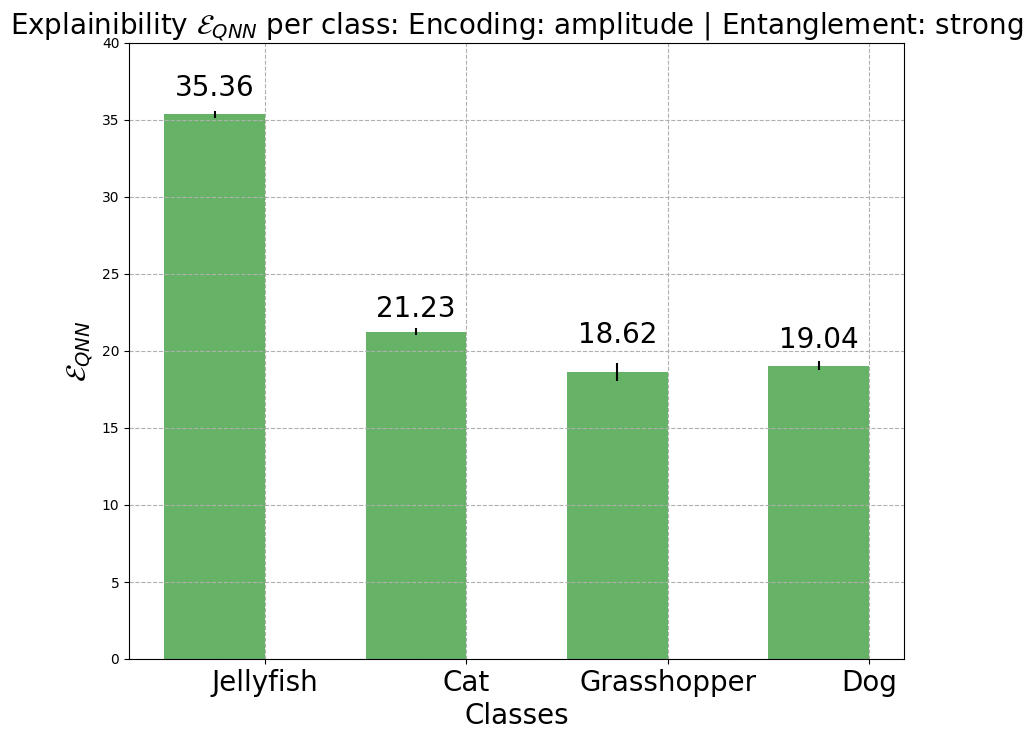

In [218]:
enocdings = ['angle','amplitude']
ansatz = ['basic','strong']
kernel_sizes = [2]
avg_df = pd.DataFrame(columns=["Encoding","Entanglement","Class",
                           "Mean Exp", "Exp Stdev", "Min Exp", "Max Exp"])

for encoding_type, ansatz_type, kernel_size in product(enocdings, ansatz, kernel_sizes):
    (exp_mean, exp_error, exp_min, exp_max) = plot_exp(encoding_type, ansatz_type)
    for i in range(4):
        row = [encoding_type, ansatz_type, i, exp_mean[i], exp_error[i], exp_min[i], exp_max[i]]
        avg_df.loc[len(avg_df)] = row

In [219]:
final_avg_df = pd.DataFrame(columns=["Encoding", "Entanglement","Mean Exp", "Exp Stdev", "Min Exp", "Max Exp"])
for encoding_type, ansatz_type, kernel_size in product(enocdings, ansatz, kernel_sizes):
    temp_df = avg_df[(avg_df.Entanglement == ansatz_type) & (avg_df.Encoding == encoding_type)]
    temp_df = (temp_df.mean(numeric_only=True))
    row = [encoding_type, ansatz_type, 
           temp_df["Mean Exp"], temp_df["Exp Stdev"], temp_df["Min Exp"], temp_df["Max Exp"]]
    final_avg_df.loc[len(final_avg_df)] = row
final_avg_df

,Encoding,Entanglement,Mean Exp,Exp Stdev,Min Exp,Max Exp
0,angle,basic,22.729478,0.196611,22.423206,23.058415
1,angle,strong,22.467496,0.198974,22.119609,22.850030
2,amplitude,basic,24.063197,0.476691,23.233108,24.767979
3,amplitude,strong,23.562148,0.326243,23.037749,24.191938
